# Добро пожаловать в Colab!

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import math

x_train = np.array([1.0, 2.0])
y_train = np.array([300.0, 500.0])

In [2]:
def compute_cost_function(x, y, w, b):
  m = x.shape[0]

  cost_sum = 0

  for i in range(m):
    f_wb = x[i] * w  + b
    cost_ = (f_wb - y[i]) ** 2
    cost_sum += cost_

  total = (1/(2 * m)) * cost_sum

  return total

In [3]:
def compute_gradient(x, y, w, b):
  dj_db = 0
  dj_dw = 0

  m = x.shape[0]

  for i in range(m):
    f_wb = x[i] * w + b

    dj_dw_i = (f_wb - y[i]) * x[i]
    dj_db_i = (f_wb - y[i])

    dj_db += dj_db_i
    dj_dw += dj_dw_i

  dj_dw = dj_dw / m
  dj_db = dj_db / m

  return dj_dw, dj_db

In [5]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):
    J_history =  []
    p_history = []

    b = b_in
    w = w_in

    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(x,y, w, b)

        b = b - alpha * dj_db
        w = w - alpha * dj_dw

        if i < 10_000:
            J_history.append(cost_function(x, y, w, b))
            p_history.append([w,b])

        if i% math.ceil(num_iters / 10) == 0:
          print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
                    f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",
                    f"w: {w: 0.3e}, b:{b: 0.5e}")

    return w, b,  J_history,  p_history

In [8]:
w_init = 0
b_init = 0

iterations = 20_000
tmp_alpha = 1.0e-2

w_final, b_final, J_hist, p_hist = gradient_descent(x_train,
                                                    y_train,
                                                    w_in = w_init,
                                                    b_in = b_init,
                                                    alpha = tmp_alpha,
                                                    num_iters = iterations,
                                                    cost_function = compute_cost_function,
                                                    gradient_function = compute_gradient)

print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

Iteration    0: Cost 7.93e+04  dj_dw: -6.500e+02, dj_db: -4.000e+02   w:  6.500e+00, b: 4.00000e+00
Iteration 2000: Cost 7.93e-01  dj_dw: -1.789e-01, dj_db:  2.895e-01   w:  1.975e+02, b: 1.03966e+02
Iteration 4000: Cost 4.28e-02  dj_dw: -4.158e-02, dj_db:  6.727e-02   w:  1.994e+02, b: 1.00922e+02
Iteration 6000: Cost 2.31e-03  dj_dw: -9.660e-03, dj_db:  1.563e-02   w:  1.999e+02, b: 1.00214e+02
Iteration 8000: Cost 1.25e-04  dj_dw: -2.245e-03, dj_db:  3.632e-03   w:  2.000e+02, b: 1.00050e+02
Iteration 10000: Cost 6.75e-06  dj_dw: -5.215e-04, dj_db:  8.439e-04   w:  2.000e+02, b: 1.00012e+02
Iteration 12000: Cost 6.75e-06  dj_dw: -1.212e-04, dj_db:  1.961e-04   w:  2.000e+02, b: 1.00003e+02
Iteration 14000: Cost 6.75e-06  dj_dw: -2.816e-05, dj_db:  4.556e-05   w:  2.000e+02, b: 1.00001e+02
Iteration 16000: Cost 6.75e-06  dj_dw: -6.542e-06, dj_db:  1.059e-05   w:  2.000e+02, b: 1.00000e+02
Iteration 18000: Cost 6.75e-06  dj_dw: -1.520e-06, dj_db:  2.459e-06   w:  2.000e+02, b: 1.00000

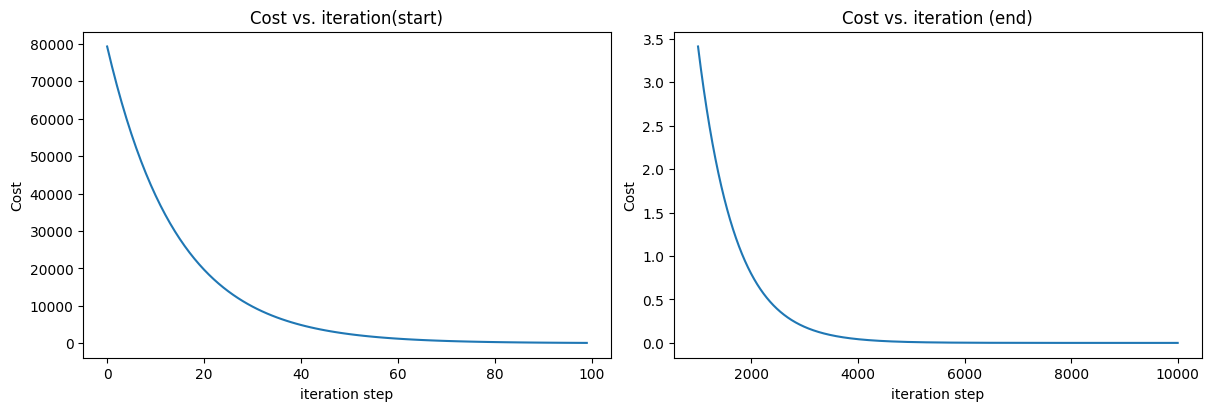

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J_hist[:100])
ax2.plot(1000 + np.arange(len(J_hist[1000:])), J_hist[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost')
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step')
plt.show()